# SEA single-drift experiment
Debug notebook for the DNN + Autoencoder concept drift detection pipeline.

In [17]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import os
import numpy as np
import matplotlib.pyplot as plt

from helpers import (
    configure_matplotlib,
    rolling_mean,
    add_drift_markers,
    plot_sea_data,
    collect_capymoa_samples,
)

from tscls.pipeline.detector import AEDriftDetector
from tscls.pipeline.monitor import StreamMonitor
from tscls.pipeline.pipeline_config import (
    PipelineConfig,
    DNNModelConfig,
    AutoencoderConfig,
    OptimizationConfig,
    TrainingConfig,
)
from capymoa.stream import NumpyStream
from capymoa.stream.generator import SEA as CapySEA
from capymoa.stream.drift import DriftStream, Drift

configure_matplotlib()

FIGURES_DIR = "figures/dnn_ae"
os.makedirs(FIGURES_DIR, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [18]:
n1        = 5_000   # reference samples
n2        = 10_000  # stream samples  (paper Table 1: SEA_a = 10 000)
drift_pos = 5_000   # stream index at which concept changes (paper: 5000)
seed      = 0

# capymoa SEA function IDs (MOA convention) and their decision thresholds θ
CAPYMOA_SEA_THRESHOLDS = {1: 8.0, 2: 9.0, 3: 7.0, 4: 9.5}
f_old_moa = 4   # θ=9.5
f_new_moa = 3   # θ=7.0
theta_old = CAPYMOA_SEA_THRESHOLDS[f_old_moa]
theta_new = CAPYMOA_SEA_THRESHOLDS[f_new_moa]

## Data generation

In [19]:
# Reference data
sea_ref = CapySEA(
    function=f_old_moa,
    instance_random_seed=seed,
    noise_percentage=0,
    balance_classes=True,
)
X_ref, y_ref = collect_capymoa_samples(sea_ref, n1)

# Stream — pre-collect for visualisation, then restart for the monitor
drift_stream = DriftStream(stream=[
    CapySEA(function=f_old_moa, instance_random_seed=seed + 10, noise_percentage=0),
    Drift(position=drift_pos, width=0),
    CapySEA(function=f_new_moa, instance_random_seed=seed + 20, noise_percentage=0),
])
X_stream, y_stream = collect_capymoa_samples(drift_stream, n2)
drift_stream.restart()

print(f"Reference : {X_ref.shape}  classes={np.unique(y_ref,    return_counts=True)[1]}")
print(f"Stream    : {X_stream.shape}  classes={np.unique(y_stream, return_counts=True)[1]}")

Reference : (5000, 3)  classes=[2500 2500]
Stream    : (10000, 3)  classes=[3432 6568]


## Training and stream time series

The SEA decision boundary depends on $x_0 + x_1 \leq \theta$.
Plotting that sum makes the concept shift visible.

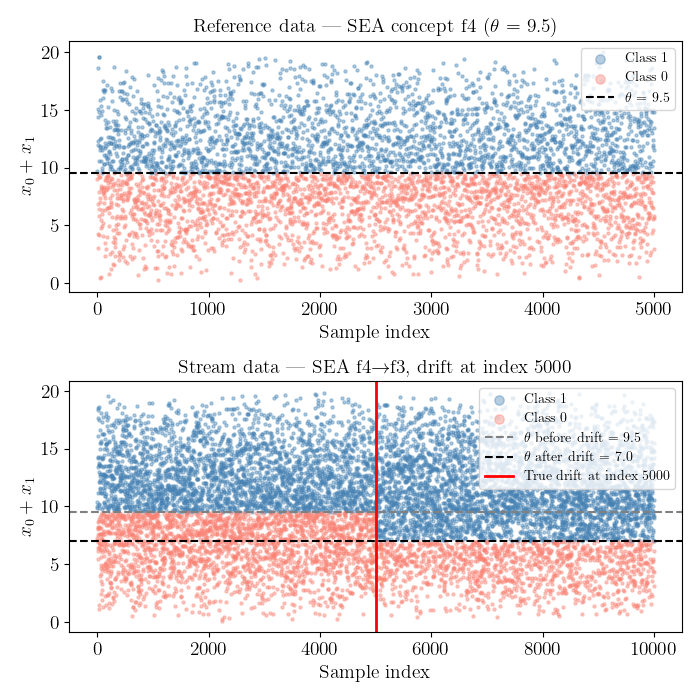

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7))
plot_sea_data(
    axes,
    X_ref, y_ref,
    X_stream, y_stream,
    theta_old, theta_new,
    f_old_moa, f_new_moa,
    drift_pos,
)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "sea_data.pdf"), bbox_inches="tight")
plt.show()

## Pipeline configuration

In [21]:
def build_config(num_features: int) -> PipelineConfig:
    return PipelineConfig(
        model=DNNModelConfig(
            layer_sizes=[num_features, 256, 128, 64, 1],
        ),
        autoencoder=AutoencoderConfig(
            encoder_sizes=[64, 8],   # paper Table 5: L_A = 8
            activation="relu",
            threshold_k=3.0,
        ),
        optimization=OptimizationConfig(
            model1_loss_name="bce_with_logits",
            model2_loss_name="bce_with_logits",
            model3_loss_name="mse",
            model1_optimizer_name="sgd",
            model2_optimizer_name="sgd",
            model3_optimizer_name="adam",
            model1_learning_rate=1e-2,
            model2_learning_rate=1e-4,
            model3_learning_rate=1e-4,
            gamma1=0.9,
            s1=20,
            gamma2=1.0,
            s2=10,
        ),
        training=TrainingConfig(
            model1_epochs=1_000,
            model3_epochs=4_000,
            batch_size=256,
        ),
    )

config = build_config(num_features=X_ref.shape[1])

## Offline training

In [22]:
detector = AEDriftDetector(config=config)
print(f"Training on: {detector.device}")
detector.fit(X_ref, y_ref)
print("Offline training complete.")

Training on: cuda
Offline training complete.


## Training loss curves

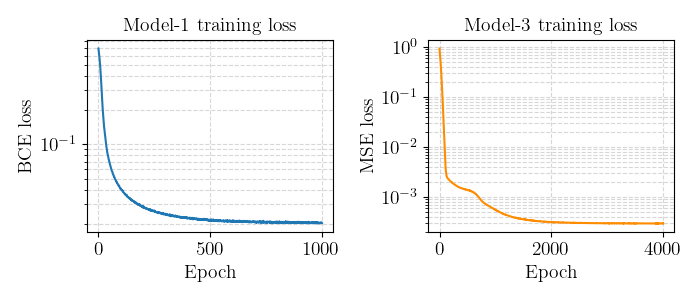

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].plot(detector.model1_train_losses)
axes[0].set_yscale("log")
axes[0].set_title("Model-1 training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].grid(True, which="both", linestyle="--", alpha=0.5)

axes[1].plot(detector.model3_train_losses, color="darkorange")
axes[1].set_yscale("log")
axes[1].set_title("Model-3 training loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE loss")
axes[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "training_losses.pdf"), bbox_inches="tight")
plt.show()

## Online stream monitoring

In [24]:
monitor = StreamMonitor(detector=detector)
stream  = NumpyStream(X_stream, y_stream, dataset_name="SEA_stream")
result  = monitor.run(stream)

print(f"Detected drift points (first 20): {result.drift_points[:20]}")
print(f"Total detected: {len(result.drift_points)}")
if result.drift_points:
    delay = result.drift_points[0] - drift_pos
    print(f"First detected at index {result.drift_points[0]}  (delay = {delay})")
else:
    print("No drift detected.")

Detected drift points (first 20): [45, 54, 105, 115, 159, 223, 226, 229, 344, 349, 442, 449, 457, 462, 578, 620, 633, 733, 814, 865]
Total detected: 1043
First detected at index 45  (delay = -4955)


## Detection results

Reconstruction error over the stream, with the calibrated threshold band,
the true drift position, and the detected drift points.

In [25]:
errors = np.array(result.reconstruction_errors)
losses = np.array(result.training_losses)
preds  = np.array(result.predictions)

stats      = detector.threshold_rule.stats   # ThresholdStat: .mean .std .lower .upper
stream_idx = np.arange(len(errors))

window     = 100
is_correct = (np.round(preds) == y_stream).astype(float)
rolling_acc, rolling_idx = rolling_mean(is_correct, window)

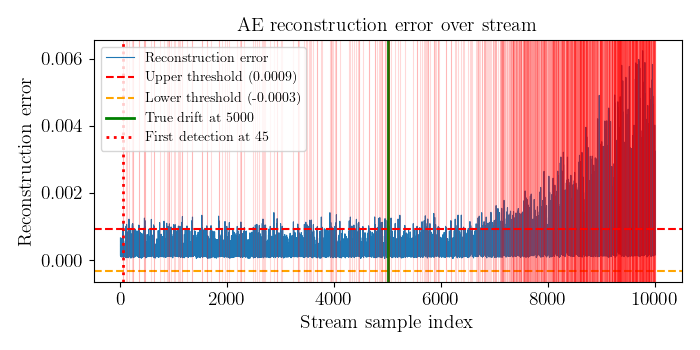

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.plot(stream_idx, errors, linewidth=0.8, label="Reconstruction error")
ax.axhline(
    stats.upper,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
add_drift_markers(
    ax,
    drift_pos,
    result.drift_points,
    first_label=f"First detection at {result.drift_points[0]}",
)
ax.set_title("AE reconstruction error over stream")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper left")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "reconstruction_error.pdf"), bbox_inches="tight")
plt.show()

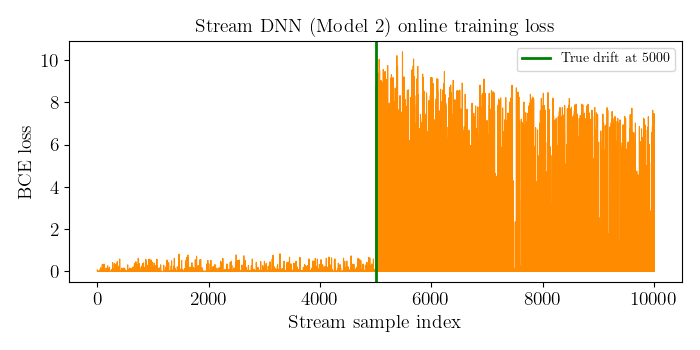

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.plot(stream_idx, losses, linewidth=0.8, color="darkorange")
ax.axvline(
    drift_pos,
    color="green",
    linestyle="-",
    linewidth=2.0,
    label=f"True drift at {drift_pos}",
)
ax.set_title("Stream DNN (Model 2) online training loss")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("BCE loss")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "online_training_loss.pdf"), bbox_inches="tight")
plt.show()

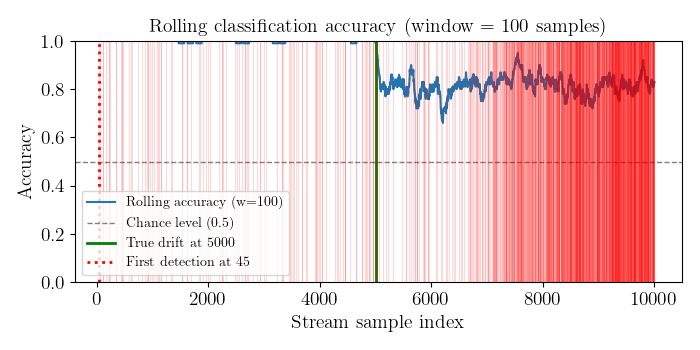

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
ax.plot(
    rolling_idx,
    rolling_acc,
    linewidth=1.5,
    label=f"Rolling accuracy (w={window})",
)
ax.axhline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.0,
    label="Chance level (0.5)",
)
add_drift_markers(
    ax,
    drift_pos,
    result.drift_points,
    first_label=f"First detection at {result.drift_points[0]}",
)
ax.set_ylim(0, 1)
ax.set_title(f"Rolling classification accuracy (window = {window} samples)")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Accuracy")
ax.legend(loc="lower left")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "rolling_accuracy.pdf"), bbox_inches="tight")
plt.show()

## Debug: reference vs stream reconstruction errors

Re-compute reconstruction errors on the reference data and compare with stream errors.
This shows whether the threshold is calibrated in a sensible range.

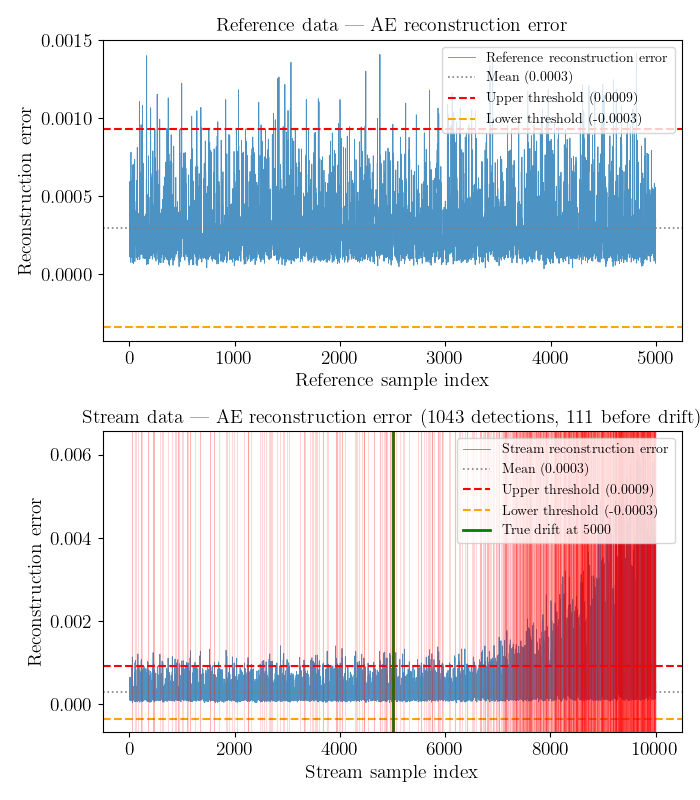

Threshold stats  — mean: 0.000295  std: 0.000212
Bounds           — lower: -0.000342  upper: 0.000932
Reference FP     — 96/5000 (1.9%)


In [29]:
import torch

detector.model1.eval()
detector.model3.eval()

x1_scaled = detector.scaler.transform(X_ref.astype(np.float32))
x1_t      = torch.tensor(x1_scaled, dtype=torch.float32).to(detector.device)

with torch.no_grad():
    _, ref_latents  = detector.model1.forward_with_latent(x1_t)
    _, ref_errors_t = detector.model3.reconstruction_error(ref_latents)

ref_errors = ref_errors_t.cpu().numpy()
ref_idx    = np.arange(len(ref_errors))

fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# --- Reference reconstruction errors ---
ax = axes[0]
ax.plot(
    ref_idx,
    ref_errors,
    linewidth=0.6,
    alpha=0.8,
    label="Reference reconstruction error",
)
ax.axhline(
    stats.mean,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label=f"Mean  ({stats.mean:.4f})",
)
ax.axhline(
    stats.upper,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
n_fp = int(np.sum((ref_errors > stats.upper) | (ref_errors < stats.lower)))
ax.set_title(
    "Reference data — AE reconstruction error"
)
ax.set_xlabel("Reference sample index")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper right")

# --- Stream reconstruction errors ---
ax = axes[1]
ax.plot(
    stream_idx,
    errors,
    linewidth=0.6,
    alpha=0.8,
    label="Stream reconstruction error",
)
ax.axhline(
    stats.mean,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label=f"Mean  ({stats.mean:.4f})",
)
ax.axhline(
    stats.upper,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Upper threshold ({stats.upper:.4f})",
)
ax.axhline(
    stats.lower,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"Lower threshold ({stats.lower:.4f})",
)
n_before = sum(d < drift_pos for d in result.drift_points)
add_drift_markers(ax, drift_pos, result.drift_points)
ax.set_title(
    f"Stream data — AE reconstruction error "
    f"({len(result.drift_points)} detections, {n_before} before drift)"
)
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Reconstruction error")
ax.legend(loc="upper right")

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "reconstruction_errors.pdf"), bbox_inches="tight")
plt.show()

print(f"Threshold stats  — mean: {stats.mean:.6f}  std: {stats.std:.6f}")
print(f"Bounds           — lower: {stats.lower:.6f}  upper: {stats.upper:.6f}")
print(f"Reference FP     — {n_fp}/{len(ref_errors)} ({100*n_fp/len(ref_errors):.1f}%)")

## Reconstruction error distributions

Overlaid histograms (density-normalized) of AE reconstruction errors **before** the true drift (stream indices `< drift_pos`) and **after** (`≥ drift_pos`), using the same `errors` array as above.

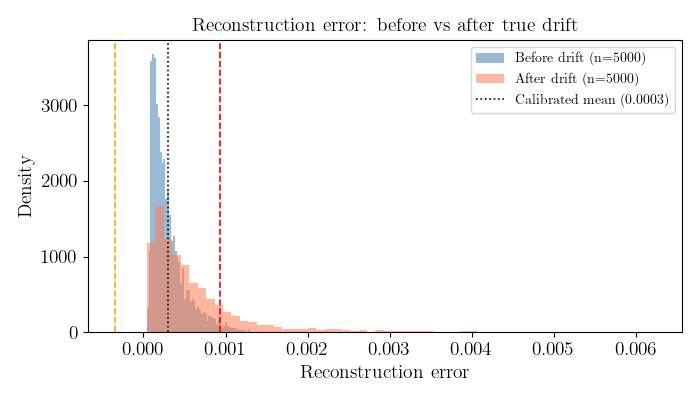

In [30]:
pre_err  = errors[:drift_pos]
post_err = errors[drift_pos:]

fig, ax = plt.subplots(figsize=(7, 4))
bins = 60
ax.hist(
    pre_err,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"Before drift (n={len(pre_err)})",
    color="steelblue",
)
ax.hist(
    post_err,
    bins=bins,
    density=True,
    alpha=0.55,
    label=f"After drift (n={len(post_err)})",
    color="coral",
)
ax.axvline(
    stats.mean,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label=f"Calibrated mean ({stats.mean:.4f})",
)
ax.axvline(stats.lower, color="orange", linestyle="--", linewidth=1.2)
ax.axvline(stats.upper, color="red",    linestyle="--", linewidth=1.2)
ax.set_xlabel("Reconstruction error")
ax.set_ylabel("Density")
ax.set_title("Reconstruction error: before vs after true drift")
ax.legend(loc="best")
# ax.set_xlim(0, 0.0025)

plt.tight_layout()

fig.savefig(os.path.join(FIGURES_DIR, "error_distributions.pdf"), bbox_inches="tight")
plt.show()

## Detected drifts over time

Histogram of detected drift events binned by their position in the stream.

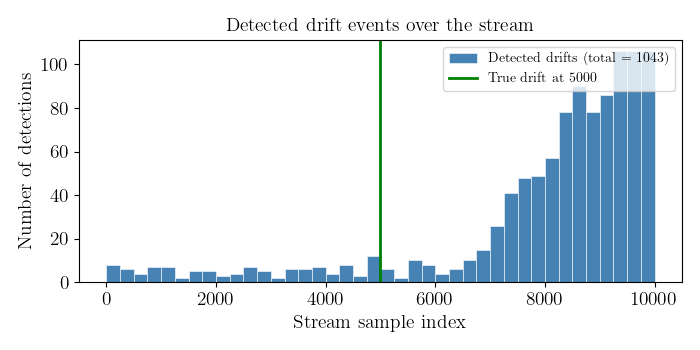

In [31]:
n_bins = 40
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(
    result.drift_points,
    bins=n_bins,
    range=(0, n2),
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
    label=f"Detected drifts (total = {len(result.drift_points)})",
)
ax.axvline(
    drift_pos,
    color="green",
    linestyle="-",
    linewidth=2.0,
    label=f"True drift at {drift_pos}",
)
ax.set_title("Detected drift events over the stream")
ax.set_xlabel("Stream sample index")
ax.set_ylabel("Number of detections")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "drift_histogram.pdf"), bbox_inches="tight")
plt.show()